# P10

Dominik Zieliński

## Diffusion-based community detection using Infomap.

References:

1. Maps of information flow reveal community structure in complex networks (2008). Martin Rosvall and Carl T. Bergstrom. arXiv:0707.0609

2. D. Edler, A. Holmgren and M. Rosvall, The MapEquation software package, available online at [mapequation.org](https://www.mapequation.org).


In [10]:
import os
import time
import re
import warnings
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from infomap import Infomap

In [11]:
warnings.filterwarnings("ignore")
COMP_DIR = "./competition"
OUT_DIR = os.path.join("./results")
os.makedirs(OUT_DIR, exist_ok=True)
RANDOM_SEED = 42

Visualizing D1-K=2.csv with 34 nodes and 78 edges.


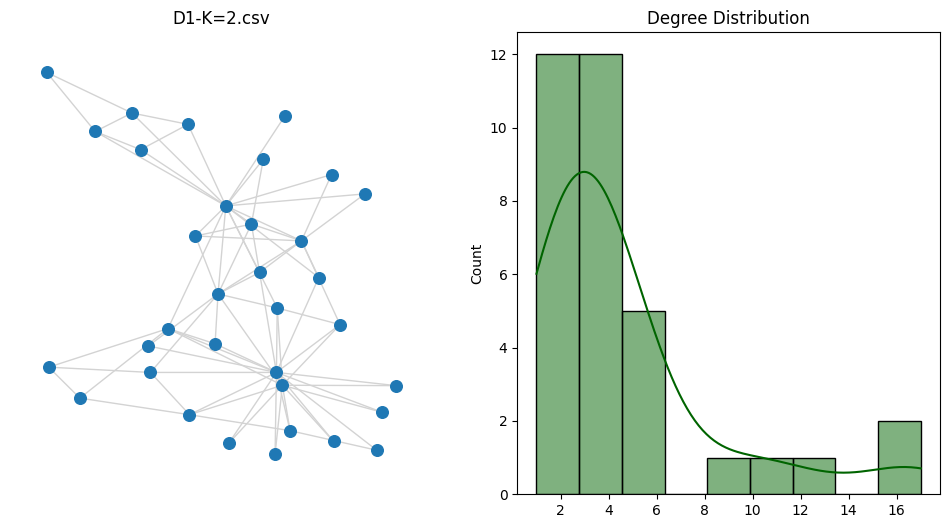

Visualizing D1-UNC.csv with 125 nodes and 334 edges.


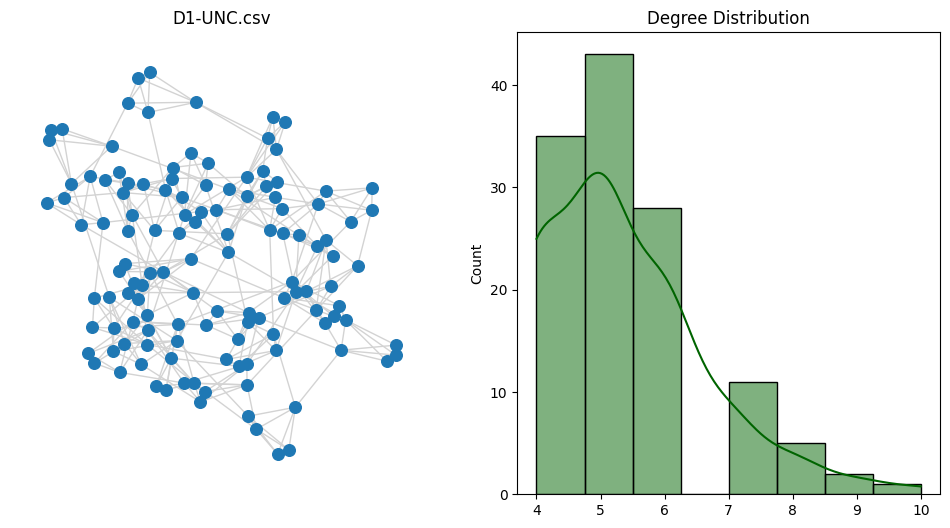

Visualizing D3-UNC.csv with 81 nodes and 487 edges.


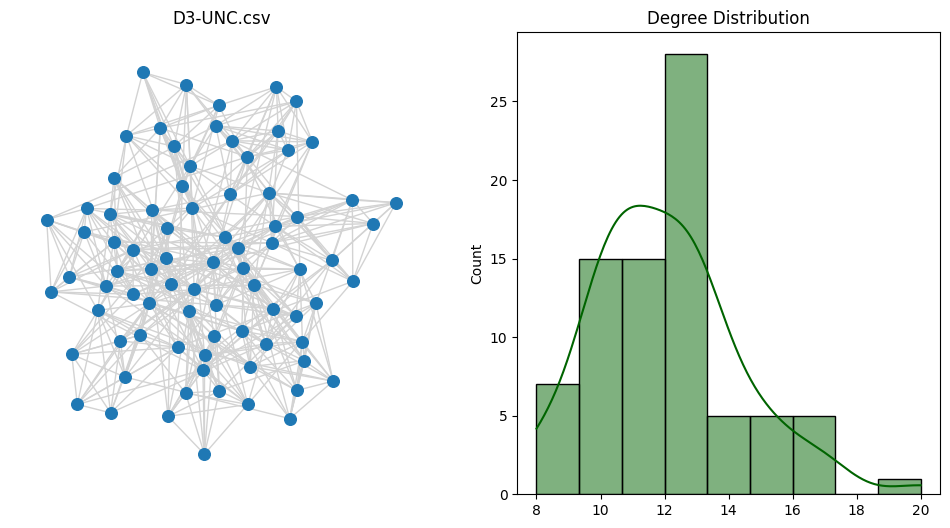

Visualizing D2-K=7.csv with 62 nodes and 159 edges.


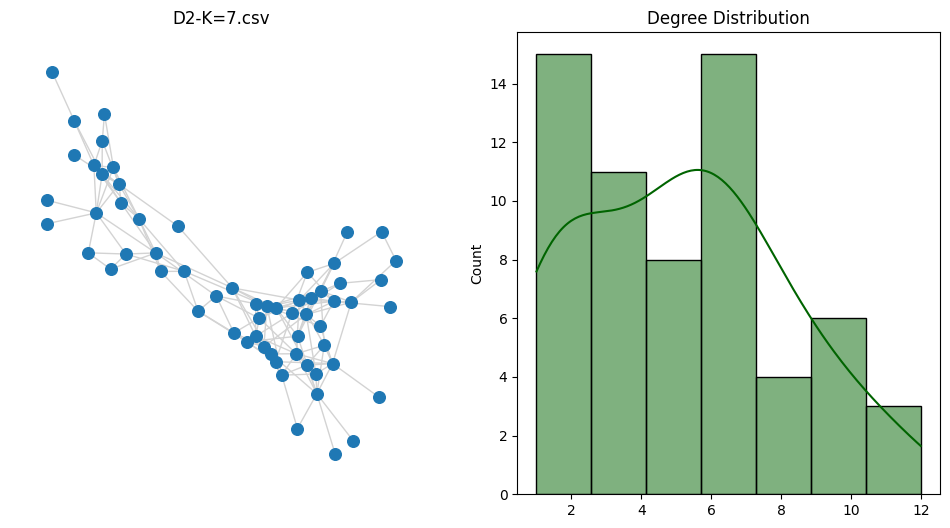

Visualizing D3-K=12.csv with 115 nodes and 613 edges.


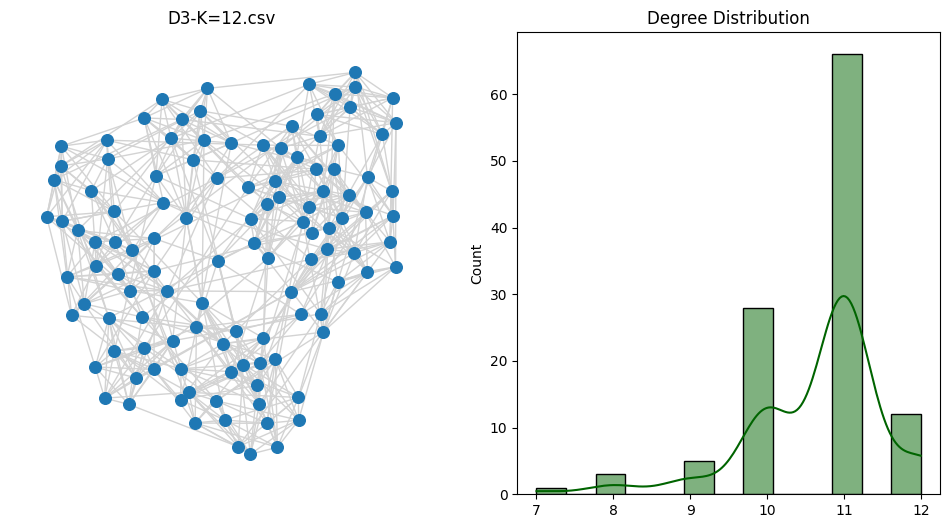

Visualizing D2-UNC.csv with 150 nodes and 940 edges.


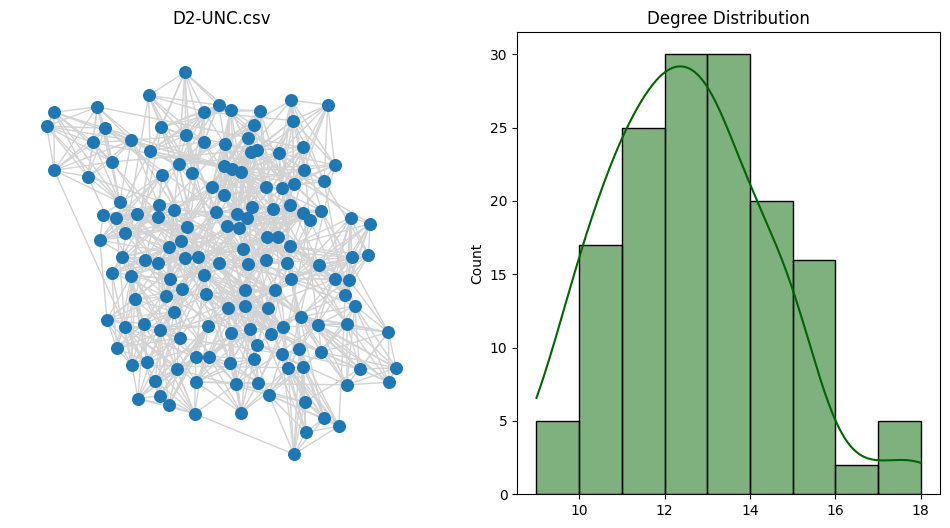

In [12]:
def load_graph_from_csv(path: str) -> nx.Graph:
    A = pd.read_csv(path, header=None).to_numpy()
    G = nx.from_numpy_array(A)
    return G


# visualize all graphs from competition
for file in os.listdir(COMP_DIR):
    if file.endswith(".csv"):
        G = load_graph_from_csv(os.path.join(COMP_DIR, file))
        print(
            f"Visualizing {file} with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges."
        )
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        nx.draw(G, edge_color="lightgray", node_size=70)
        plt.title(file)
        plt.subplot(1, 2, 2)
        degrees = [d for _, d in G.degree()]
        sns.histplot(degrees, kde=True, color="darkgreen")
        plt.title("Degree Distribution")
        plt.show()


In [22]:
NUM_TRIALS = 30
# Markov time grid for targeting known K.
MARKOV_TIME_GRID = np.logspace(-1, 1, 200)  # 0.1 .. 10.0


def parse_target_k(filename: str):
    m = re.search(r"K=(\d+)", filename)
    return int(m.group(1)) if m else None


def load_labels(path: str, n: int) -> np.ndarray:
    df = pd.read_csv(path)
    # expects columns: node, community
    labels = np.full(n, -1, dtype=int)
    labels[df["node"].to_numpy(dtype=int)] = df["community"].to_numpy(dtype=int)
    if (labels < 0).any():
        missing = np.where(labels < 0)[0]
        raise ValueError(
            f"Missing community labels for nodes: {missing[:10].tolist()} (and more)"
            if len(missing) > 10
            else f"Missing community labels for nodes: {missing.tolist()}"
        )
    return labels


def discrete_cmap(k: int):
    """
    Returns a discrete colormap with k colors.
    """
    if k <= 20:
        return plt.cm.get_cmap("tab20", k)
    return plt.cm.get_cmap("nipy_spectral", k)


def plot_partition(G: nx.Graph, labels: np.ndarray, title: str):
    k = int(len(np.unique(labels)))
    cmap = discrete_cmap(k)
    pos = nx.spring_layout(G, seed=RANDOM_SEED)
    plt.figure(figsize=(12, 8))
    nx.draw_networkx_edges(G, pos, edge_color="lightgray", width=0.8, alpha=0.8)
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=70,
        node_color=labels,
        cmap=cmap,
        linewidths=0.2,
        edgecolors="white",
    )
    plt.title(f"{title} | K={k}")
    plt.axis("off")
    plt.show()


def write_solution_file(out_path: str, labels_zero_based: np.ndarray):
    """
    Required format:
      1, number_of_cluster_containing_1
      2, number_of_cluster_containing_2
      ...
    Vertices are 1..n, clusters are consecutive natural numbers.
    """
    labels_one_based = labels_zero_based + 1
    with open(out_path, "w", encoding="utf-8") as f:
        for v0, c in enumerate(labels_one_based):
            f.write(f"{v0 + 1}, {int(c)}\n")

In [23]:
def run_infomap(G: nx.Graph, options: str):
    """
    Run Infomap and return (labels, k_found, codelength).
    Uses the Python API option-string style as shown in official examples.
    """
    im = Infomap()
    im.add_networkx_graph(G)
    im.run(options)

    modules = im.get_modules()  # node -> module_id
    n = G.number_of_nodes()
    labels = np.zeros(n, dtype=int)
    for i in range(n):
        labels[i] = int(modules[i])

    uniq = {m: idx for idx, m in enumerate(sorted(set(labels)))}
    labels = np.array([uniq[m] for m in labels], dtype=int)
    k_found = len(uniq)
    codelength = float(im.codelength)
    return labels, k_found, codelength


def infomap_partition(G: nx.Graph, target_k: int | None):
    """
    If target_k is provided, try to hit it by scanning Markov time and using
    --preferred-number-of-modules to bias solutions toward K.

    NOTE: Infomap doesn't guarantee exact K; this searches for a run that yields it.
    """
    base = f"--two-level --silent --seed {RANDOM_SEED} --num-trials {NUM_TRIALS}"

    if target_k is None:
        # Single run for unknown K (Infomap chooses K)
        opts = f"{base} --markov-time 1"
        labels, k_found, L = run_infomap(G, opts)
        return labels, k_found, 1.0, L

    # Known K: search markov time for exact match; if none, choose closest (tie: lower codelength)
    best = None  # (abs_diff, codelength, markov_time, labels, k_found)
    for t in MARKOV_TIME_GRID:
        # "preferred number of modules" biases but does not hard-constrain.
        opts = f"{base} --preferred-number-of-modules {target_k} --markov-time {t}"
        labels, k_found, L = run_infomap(G, opts)
        cand = (abs(k_found - target_k), L, float(t), labels, k_found)

        if best is None or cand[:2] < best[:2]:
            best = cand

        if k_found == target_k:
            # exact hit — stop early
            return labels, k_found, float(t), L

    # no exact hit
    assert best is not None
    _, L, t, labels, k_found = best
    return labels, k_found, t, L

[Infomap] D1-K=2.csv: n=34, m=78 | K_target=2 -> K_found=2 | markov_time=0.1 | codelength=3.816439 | time=0.0038s


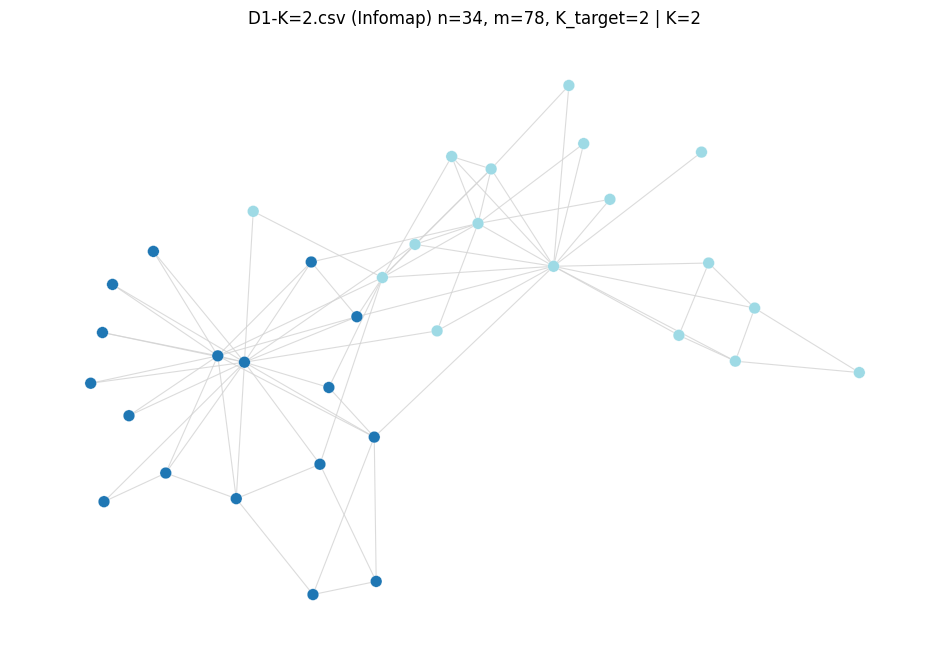

[Infomap] D1-UNC.csv: n=125, m=334 | K_target=? -> K_found=25 | markov_time=1 | codelength=4.337285 | time=0.0119s


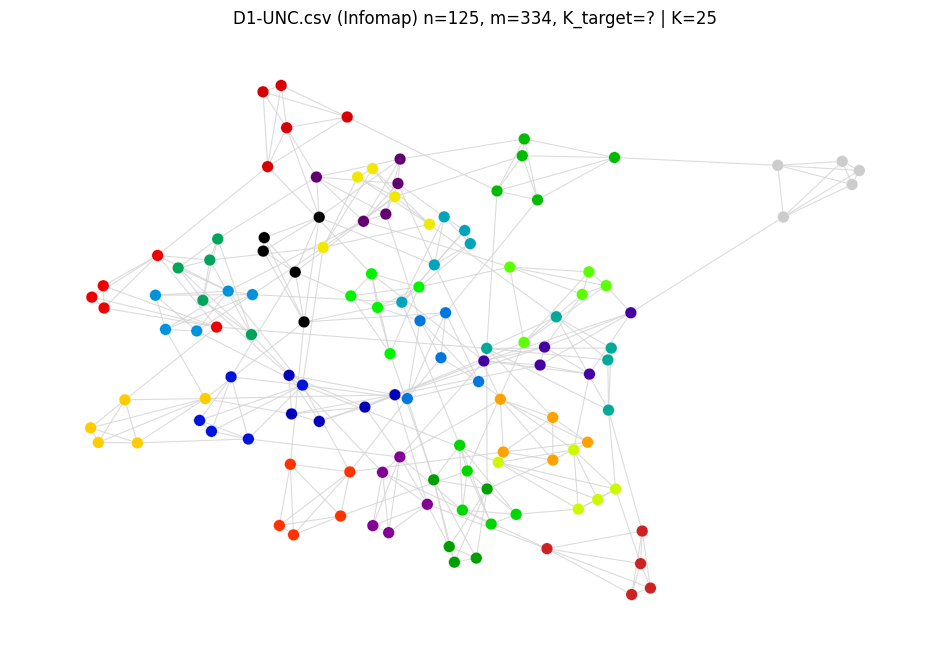

[Infomap] D2-K=7.csv: n=62, m=159 | K_target=7 -> K_found=7 | markov_time=0.1 | codelength=3.241421 | time=0.0140s


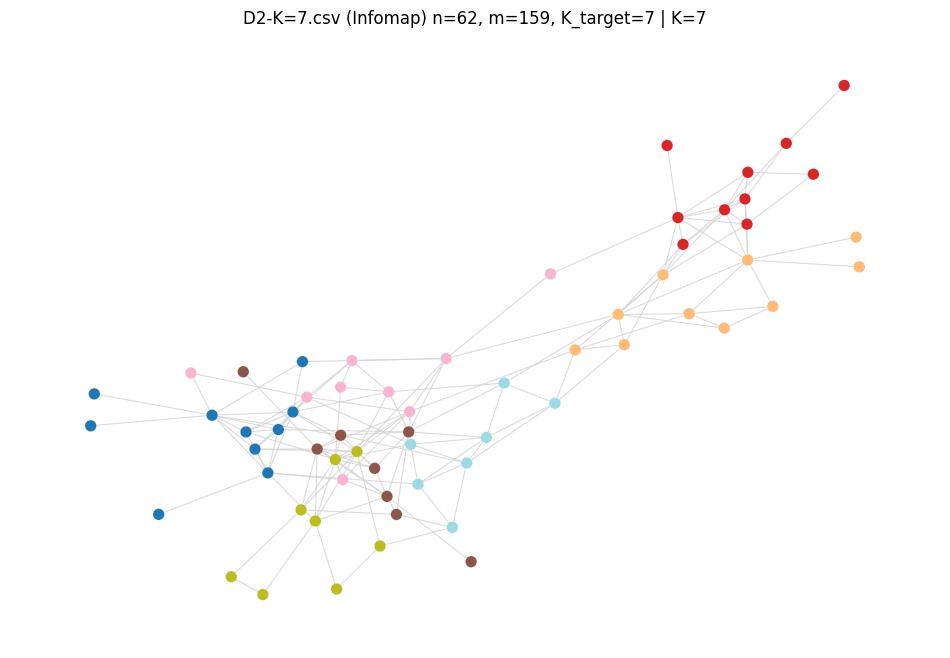

[Infomap] D2-UNC.csv: n=150, m=940 | K_target=? -> K_found=15 | markov_time=1 | codelength=5.373077 | time=0.0159s


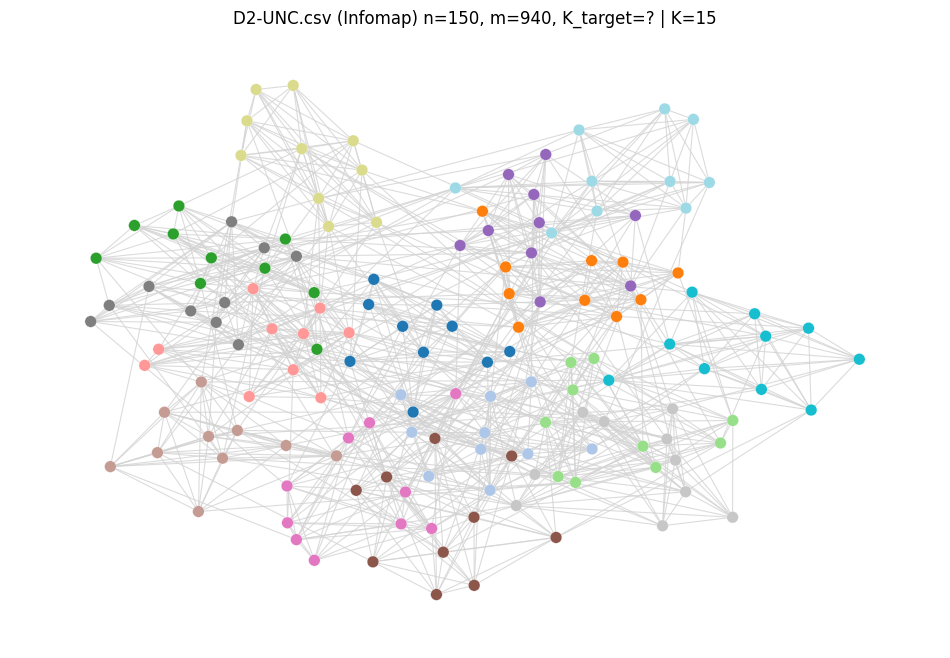

[Infomap] D3-K=12.csv: n=115, m=613 | K_target=12 -> K_found=12 | markov_time=0.1 | codelength=3.608347 | time=0.0343s


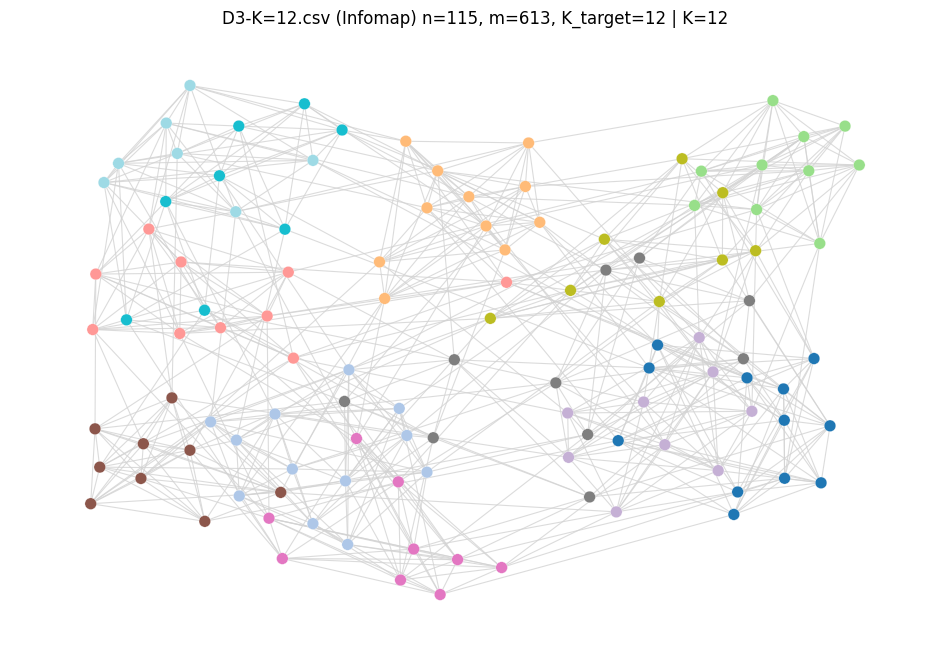

[Infomap] D3-UNC.csv: n=81, m=487 | K_target=? -> K_found=9 | markov_time=1 | codelength=5.295827 | time=0.0086s


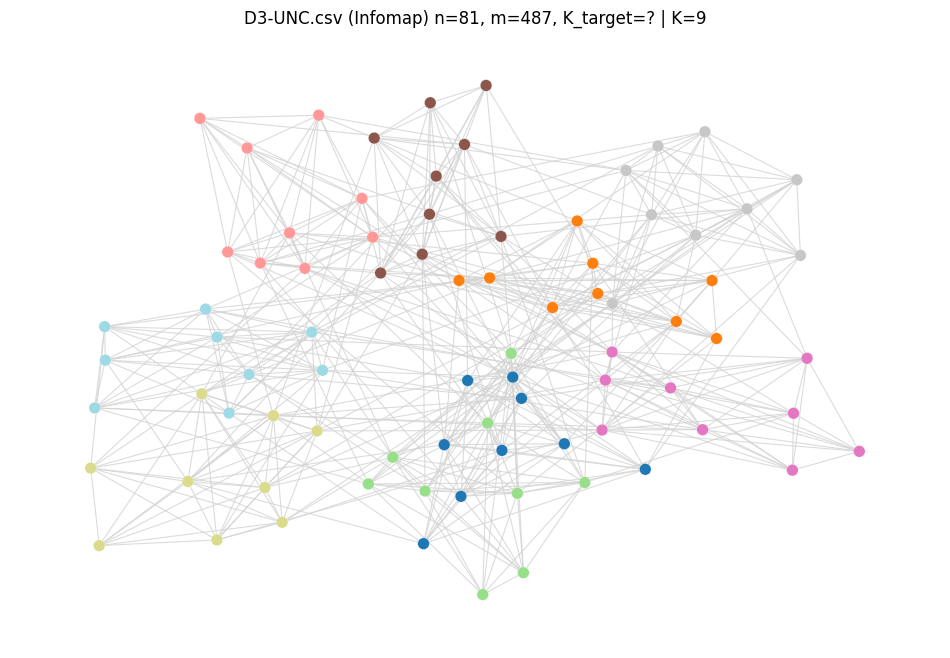


Results directory: ./results
description.txt written: ./results/description.txt


In [24]:
timings = []  # list of (filename, seconds)
# Process all benchmark graphs
for file in sorted(os.listdir(COMP_DIR)):
    if not file.endswith(".csv"):
        continue
    in_path = os.path.join(COMP_DIR, file)
    G = load_graph_from_csv(in_path)
    n, m = G.number_of_nodes(), G.number_of_edges()
    target_k = parse_target_k(file)
    t0 = time.perf_counter()
    labels, k_found, markov_time, codelength = infomap_partition(G, target_k)
    t1 = time.perf_counter()
    elapsed = t1 - t0
    timings.append((file, elapsed))
    out_path = os.path.join(OUT_DIR, file)
    write_solution_file(out_path, labels)
    print(
        f"[Infomap] {file}: n={n}, m={m} | "
        f"K_target={target_k if target_k is not None else '?'} -> K_found={k_found} | "
        f"markov_time={markov_time:.4g} | codelength={codelength:.6f} | "
        f"time={elapsed:.4f}s"
    )
    plot_partition(
        G,
        labels,
        title=f"{file} (Infomap) n={n}, m={m}, K_target={target_k if target_k is not None else '?'}",
    )
# Write description.txt in results directory
desc_path = os.path.join(OUT_DIR, "description.txt")
with open(desc_path, "w", encoding="utf-8") as f:
    f.write("Dominik Zieliński\n")
    f.write("https://github.com/dxzielinski/snars-competition\n")
    for fname, sec in timings:
        f.write(f"{fname}, {sec:.6f}\n")
print(f"\nResults directory: {OUT_DIR}")
print(f"description.txt written: {desc_path}")